Load dataset

In [9]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
df = load_breast_cancer()
print(df.feature_names)
df = pd.DataFrame(df.data, columns=df.feature_names)
print(df)


['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297

Basic structure & sanity checks
Goal: understand size, columns, data types.

How many rows and columns?
Numeric vs categorical?
Any obvious issues?

In [ ]:
print(df.head())
print(df.tail())
print(df.columns)
print(df.dtypes)
print(df.info())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

AttributeError: 'DataFrame' object has no attribute 'data'

Target variable inspection (VERY important)

Goal: understand what you’re predicting.

Class imbalance
Label encoding (0/1 or strings)

In [3]:
import matplotlib.pyplot as plt
counts = df["target"].value_counts()
print(counts)
df["target"].value_counts().plot(kind="bar")
plt.xticks([0,1], df.target_names)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


KeyError: 'target'

Missing values
Goal: find and quantify missing data.

In [ ]:
df.isnull().sum()
df.isnull().mean()


In [ ]:
print(data.feature_names)

Summary statistics
Goal: understand distributions and scale.

Large ranges
Outliers
Skewed features

Histogram — distribution & frequency

What it shows

Shape of the data (normal, skewed, multimodal)
Range and spread

Look for

Skewness (left/right)
Multiple peaks
Long tails

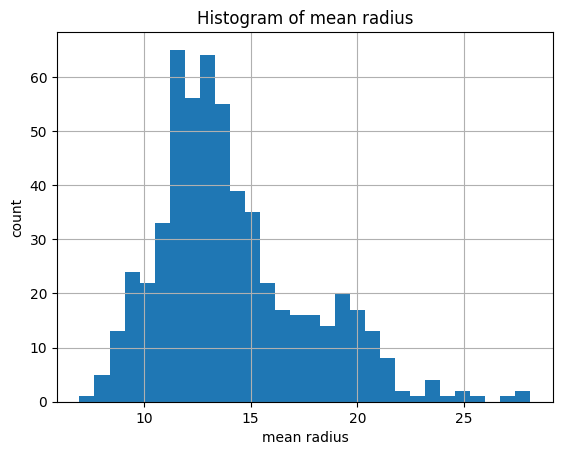

In [10]:
import matplotlib.pyplot as plt

df["mean radius"].hist(bins=30)
plt.xlabel("mean radius")
plt.ylabel("count")
plt.title("Histogram of mean radius")
plt.show()


In [ ]:


to_show = "mean concavity"
mean_rad = df[to_show][10:20] 
print(df[to_show][10:20])
df[to_show][40:60].hist(bins=30)
plt.title("Distribution of Mean Radius")
plt.xlabel(to_show)
plt.ylabel("Frequency")
plt.show()



In [ ]:
to_show = "mean smoothness"
df_to_plot = df[to_show][10:20] 
print(df[to_show][10:20])

df.boxplot(column=to_show)
plt.title("Boxplot of Mean Area")
plt.show()


In [ ]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

KDE plot — smooth probability density

What it shows

Smooth version of histogram

Easier shape comparison

Boxplot — spread & outliers

What it shows:

Median
Interquartile range (IQR)
Outliers

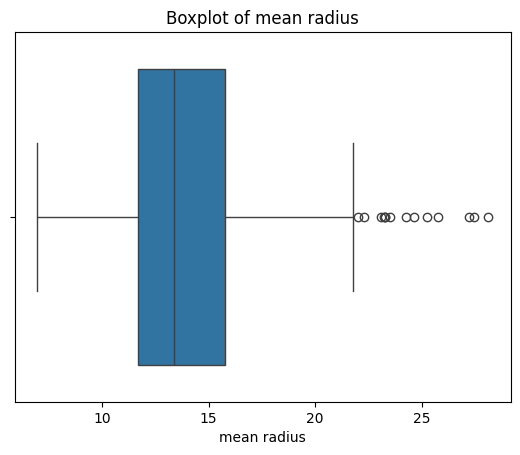

In [9]:
import seaborn as sns
sns.boxplot(x=df["mean radius"])
plt.title("Boxplot of mean radius")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
# to_show1 = "mean smoothness"
to_show1 = "mean smoothness"
# to_show2 = "perimeter error"
to_show2 = data.target

df_to_plot = df[to_show][10:20] 

sns.scatterplot(
    data=df,
    x=to_show1,
    y=to_show2,
    hue="target",
    palette="Set1"
)
vector = df[to_show1].to_numpy()

print(vector.shape)
print( to_show2.shape)
# model = LinearRegression()
# model.fit(X, y)
clf = LogisticRegression()
vector = vector.reshape(-1, 1)
clf.fit(vector, to_show2)
y_prob = clf.predict_proba(vector)[:, 1] 
boundary = -clf.intercept_[0] / clf.coef_[0][0]
plt.axvline(boundary, color='red', label='Decision boundary')
plt.show()


In [ ]:
sns.pairplot(
    df[["mean radius", "mean texture", "mean area", "target"]],
    hue="target",
    diag_kind="kde"
)
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
# to_show1 = "mean smoothness"
to_show1 = "mean smoothness"
# to_show2 = "perimeter error"
to_show2 = data.target

df_to_plot = df[to_show][10:20] 

sns.scatterplot(
    data=df,
    x=to_show1,
    y=to_show2,
    hue="target",
    palette="Set1"
)
vector = df[to_show1].to_numpy()


model = LinearRegression()
model.fit(vector, to_show2)
